## Compare TWFE and Sun-Abraham interaction-weighted estimates 
## Fig S6-S7

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# FigS_SA_vs_TWFE_k_m2_m1_data
# FigS_SA_vs_TWFE_k_m4_m1_data
# FigS_SA_vs_TWFE_all_k_lt_0_data
CSV     = "../output_linear_1999_2023/10_SA_vs_TWFE/FigS_SA_vs_TWFE_all_k_lt_0_data.csv"     # <-- path to the estimates
OUT_PNG = "output/FigS_SA_vs_TWFE_all_k_lt_0_data.png"
OUT_PDF = "output/FigS_SA_vs_TWFE_all_k_lt_0_data.pdf"
SA_REF  = "k < 0"                            # appears in the title and caption

# palette: colourblind-safe categorical slots 1-2, plus neutrals.
# blue/orange validated all-pairs on a light surface: CVD dE 24.7, normal 33.6.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTE, GRID = "#0b0b0b", "#52514e", "#8a8a86", "#e6e6e2"

BINS = ["0", "1", "2_4", "5_9", "10_14", "15_19", "20+"]
BLAB = ["0", "1", "2-4", "5-9", "10-14", "15-19", "20+"]
CROP_LAB = {"corn": "Corn", "soy": "Soybean"}

# identity is carried by colour, linestyle AND marker fill, so it survives greyscale
# printing and colour-vision deficiency. dx dodges the two series horizontally.
STYLE = {"TWFE":           dict(c=BLUE,   ls="-",        mk="o", mfc=BLUE,    dx=-0.085),
         "Sun-Abraham IW": dict(c=ORANGE, ls=(0, (3, 2)), mk="o", mfc="white", dx=+0.085)}

## Load

In [8]:
df = pd.read_csv(CSV)
df["x"] = df["bin"].map({b: i for i, b in enumerate(BINS)})
print(df.groupby("estimator")["bin"].count().to_string())

estimator
Sun-Abraham IW    14
TWFE              14


## Draw

The only fiddly part is the value labels at the `20+` bin. Offsetting one estimator up and
the other down unconditionally fails whenever the series cross — for corn under this
reference Sun–Abraham sits *above* TWFE, so a fixed rule pushes the labels together. The
code below nudges whichever value is **higher** upward and the lower one down, which is
robust to either ordering.

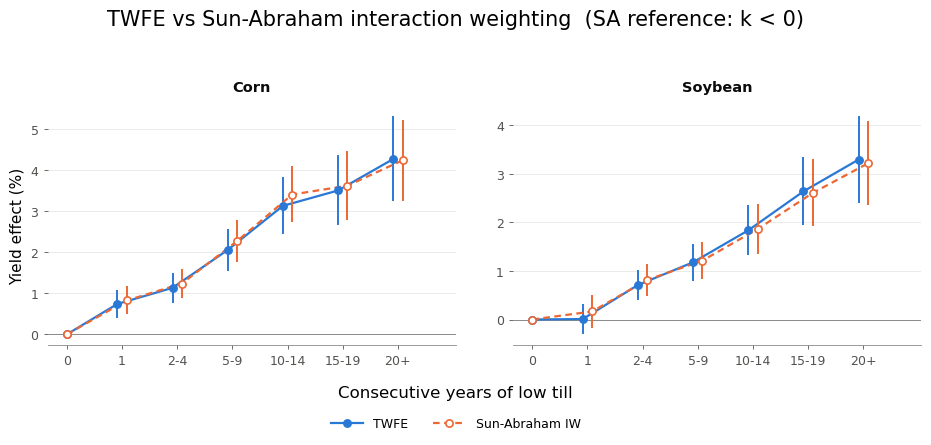

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.8))

for ax, crop in zip(axes, ["corn", "soy"]):
    sub = df[df["crop"] == crop]
    ymax = sub["pct"].max()
    for est, s in STYLE.items():
        d = sub[sub["estimator"] == est].sort_values("x")
        xd = d["x"] + np.where(d["bin"] == "0", 0.0, s["dx"])   # ref bin is not dodged
        ax.plot(xd, d["pct"], ls=s["ls"], color=s["c"], lw=1.6, zorder=2)
        ax.vlines(xd, d["pct_lo"], d["pct_hi"], color=s["c"], lw=1.4, zorder=2)
        ax.plot(xd, d["pct"], s["mk"], color=s["c"], mfc=s["mfc"],
                mew=1.2, ms=5.2, zorder=3)

        # label the 20+ value: higher one up, lower one down
        last = d[d["bin"] == "20+"].iloc[0]
        top = sub[sub["bin"] == "20+"]["pct"].max()
        off = 0.085 * ymax * (1 if last["pct"] == top else -1)
        # ax.text(last["x"] + s["dx"] + 0.16, last["pct"] + off,
        #         f"{last['pct']:+.2f}%", color=s["c"], fontsize=8.6,
        #         fontweight="bold", va="center", ha="left")

    ax.axhline(0, color=MUTE, lw=0.7, zorder=1)
    ax.set_title(CROP_LAB[crop], fontsize=10.5, fontweight="bold", color=INK, pad=10)
    ax.set_xticks(range(len(BINS)))
    ax.set_xticklabels(BLAB)
    ax.set_xlim(-0.35, len(BINS) - 1 + 1.05)       # room on the right for the labels
    ax.yaxis.grid(True, color=GRID, lw=0.6)         # recessive grid, horizontal only
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_color(MUTE)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(colors=INK2, labelsize=9, length=3, width=0.6)

axes[0].set_ylabel("Yield effect (%)", fontsize=11)
fig.supxlabel("Consecutive years of low till", fontsize=12, y=0.085)

handles = [Line2D([0], [0], color=s["c"], ls=s["ls"], lw=1.6, marker=s["mk"],
                  mfc=s["mfc"], mew=1.2, ms=5.2, label=k) for k, s in STYLE.items()]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.0),
           ncol=2, frameon=False, fontsize=9, handlelength=2.6)

fig.suptitle(f"TWFE vs Sun-Abraham interaction weighting  (SA reference: {SA_REF})",
             x=0.5, y=0.9, ha="center", fontsize=15)
# fig.text(0.045, 0.925,
#          "Both use field + year fixed effects, the same weather controls, area weights and "
#          "county-clustered SEs.\nBins matched to the Sun-Abraham relative periods "
#          "(duration = k + 1). Bars are 95% CIs.",
#          ha="left", va="top", fontsize=9, color=INK2)
# fig.text(0.045, 0.015,
#          "Reference = 0 low-till years for TWFE. The Sun-Abraham reference here folds "
#          f"{SA_REF} into the omitted category, so only the\npost-adoption profile is "
#          "comparable. Sun-Abraham aggregation weights are cohort area shares, "
#          "non-negative by construction.",
#          ha="left", va="bottom", fontsize=7.3, color=MUTE)

fig.subplots_adjust(left=0.075, right=0.985, top=0.70, bottom=0.20, wspace=0.14)
plt.show()

## Save

In [5]:
fig.savefig(OUT_PNG, dpi=320)
fig.savefig(OUT_PDF)                 # vector, for the manuscript
print("wrote", OUT_PNG, "and", OUT_PDF)

wrote output/FigS_SA_vs_TWFE_k_m4_m1.png and output/FigS_SA_vs_TWFE_k_m4_m1.pdf
